In [13]:
# Cell 1: Imports + load provider-level data for modeling

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import pickle

# Make plots a bit nicer
sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)

# 1) Load the provider-level dataset created in notebook 01
data_path = "../data/processed/"
provider_df = pd.read_csv(os.path.join(data_path, "provider_df.csv"))

print("provider_df shape:", provider_df.shape)
provider_df.head()


provider_df shape: (5410, 33)


,Provider,ip_claim_count,ip_bene_count,ip_reimb_sum,ip_reimb_mean,ip_admit_days_sum,ip_claim_days_sum,ip_diag_mean,ip_has_operating_rate,op_claim_count,op_bene_count,op_reimb_sum,op_reimb_mean,op_claim_days_sum,op_diag_mean,op_has_operating_rate,provider_bene_count,provider_age_mean,provider_age_std,provider_dead_rate,ChronicCond_Alzheimer_mean,ChronicCond_Heartfailure_mean,ChronicCond_Cancer_mean,total_claim_count,total_reimb_sum,reimb_per_claim,claims_per_bene,reimb_per_bene,ip_claim_share,op_claim_share,total_claim_days_sum,days_per_claim,FraudLabel
0,PRV51001,5.0,5.0,97000.0,19400.000000,30.0,30.0,7.200000,0.400000,20.0,19.0,7640.0,382.000000,31.0,2.200000,0.150000,24,78.669747,12.189902,0.000000,1.416667,1.250000,1.791667,25.0,104640.0,4185.599833,1.041667,4359.999818,0.200000,0.800000,61.0,2.440000,0
1,PRV51003,62.0,53.0,573000.0,9241.935484,382.0,382.0,8.112903,0.645161,70.0,66.0,32670.0,466.714286,235.0,2.714286,0.071429,117,69.473666,13.265545,0.008547,1.623932,1.401709,1.914530,132.0,605670.0,4588.409056,1.128205,5176.666622,0.469697,0.530303,617.0,4.674242,1
2,PRV51004,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,149.0,138.0,52170.0,350.134228,362.0,2.583893,0.181208,138,72.946086,12.909559,0.007246,1.565217,1.405797,1.884058,149.0,52170.0,350.134226,1.079710,378.043476,0.000000,1.000000,362.0,2.429530,0
3,PRV51005,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1165.0,495.0,280910.0,241.124464,2433.0,2.588841,0.190558,495,70.517540,13.608518,0.006061,1.666667,1.468687,1.880808,1165.0,280910.0,241.124463,2.353535,567.494948,0.000000,1.000000,2433.0,2.088412,1
4,PRV51007,3.0,3.0,19000.0,6333.333333,19.0,19.0,7.333333,0.333333,69.0,56.0,14710.0,213.188406,122.0,2.797101,0.159420,58,68.486582,14.509705,0.017241,1.637931,1.482759,1.896552,72.0,33710.0,468.194438,1.241379,581.206887,0.041667,0.958333,141.0,1.958333,0


In [14]:
# Cell 2: Define X (features), y (target), and row_id

# We keep a row_id to know which rows belong to the test set later
provider_df["row_id"] = np.arange(len(provider_df))

# Target column (created in notebook 01)
y = provider_df["FraudLabel"].astype(int)

# Columns we do NOT want to use as features
drop_cols = ["FraudLabel", "Provider", "row_id"]

feature_cols = [c for c in provider_df.columns if c not in drop_cols]

X = provider_df[feature_cols]
row_ids = provider_df["row_id"]

print("Number of features:", len(feature_cols))
print("First few feature columns:", feature_cols[:10])
print("Fraud ratio (overall):", y.mean())


Number of features: 31
First few feature columns: ['ip_claim_count', 'ip_bene_count', 'ip_reimb_sum', 'ip_reimb_mean', 'ip_admit_days_sum', 'ip_claim_days_sum', 'ip_diag_mean', 'ip_has_operating_rate', 'op_claim_count', 'op_bene_count']
Fraud ratio (overall): 0.09353049907578559


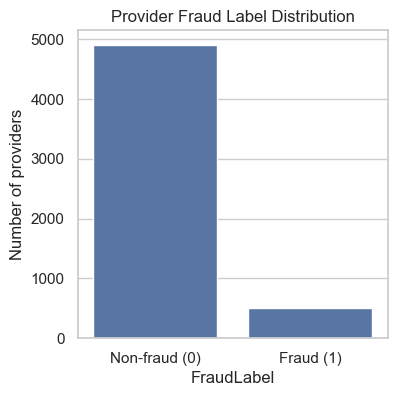

Number of non-fraud providers: 4904
Number of fraud providers: 506
Fraud percentage: 9.35 %


In [15]:
# Cell 3: Class imbalance visualization (for report)

plt.figure(figsize=(4, 4))
sns.countplot(x=y)
plt.xticks([0, 1], ["Non-fraud (0)", "Fraud (1)"])
plt.title("Provider Fraud Label Distribution")
plt.xlabel("FraudLabel")
plt.ylabel("Number of providers")
plt.show()

print("Number of non-fraud providers:", (y == 0).sum())
print("Number of fraud providers:", (y == 1).sum())
print("Fraud percentage:", round(100 * y.mean(), 2), "%")


In [16]:
# Cell 4: Train / validation / test split (60% / 20% / 20%)

# First split: train vs (val+test)
X_train, X_temp, y_train, y_temp, row_train, row_temp = train_test_split(
    X, y, row_ids,
    test_size=0.4,        # 40% of data goes to temp
    stratify=y,           # preserve fraud ratio
    random_state=42
)

# Second split: validation vs test (from temp)
X_val, X_test, y_val, y_test, row_val, row_test = train_test_split(
    X_temp, y_temp, row_temp,
    test_size=0.5,        # 50% of the 40% → 20% of total
    stratify=y_temp,
    random_state=42
)

print("X_train:", X_train.shape, "  y_train fraud ratio:", y_train.mean())
print("X_val:  ", X_val.shape,   "  y_val fraud ratio:  ", y_val.mean())
print("X_test: ", X_test.shape,  "  y_test fraud ratio: ", y_test.mean())


X_train: (3246, 31)   y_train fraud ratio: 0.09365372766481823
X_val:   (1082, 31)   y_val fraud ratio:   0.0933456561922366
X_test:  (1082, 31)   y_test fraud ratio:  0.0933456561922366


In [17]:
# Cell 5: Helper function to evaluate a trained model on validation data

def evaluate_on_validation(model_name, model, X_val, y_val):
    """
    Given a trained model and validation data, compute:
      - Precision, Recall, F1 (binary)
      - ROC-AUC
      - PR-AUC (Average Precision)
    and return a dict with metrics and predictions.
    """
    # Hard predictions 0/1
    y_pred = model.predict(X_val)

    # Probabilities for class 1 (fraud) if available
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        # Some models (e.g., SVC without probability=True) use decision_function
        scores = model.decision_function(X_val)
        # Scale scores to [0,1] so we can use them as "pseudo-probabilities"
        s_min, s_max = scores.min(), scores.max()
        y_proba = (scores - s_min) / (s_max - s_min + 1e-9)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, y_pred, average="binary", zero_division=0
    )

    roc = roc_auc_score(y_val, y_proba)
    pr_auc = average_precision_score(y_val, y_proba)

    print(f"\n=== {model_name} on VALIDATION set ===")
    print("Precision:", round(precision, 3))
    print("Recall   :", round(recall, 3))
    print("F1-score :", round(f1, 3))
    print("ROC-AUC  :", round(roc, 3))
    print("PR-AUC   :", round(pr_auc, 3))

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc,
        "pr_auc": pr_auc,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


In [18]:
# Cell 6: Logistic Regression (interpretable baseline)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # penalize mistakes on the minority class more
    solver="liblinear"
)

log_reg.fit(X_train, y_train)

lr_results = evaluate_on_validation("Logistic Regression", log_reg, X_val, y_val)



=== Logistic Regression on VALIDATION set ===
Precision: 0.418
Recall   : 0.861
F1-score : 0.563
ROC-AUC  : 0.947
PR-AUC   : 0.74


In [19]:
# Cell 7: Decision Tree (simple nonlinear model, still interpretable)

tree = DecisionTreeClassifier(
    max_depth=5,            # limit depth to avoid overfitting
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

tree_results = evaluate_on_validation("Decision Tree", tree, X_val, y_val)



=== Decision Tree on VALIDATION set ===
Precision: 0.352
Recall   : 0.881
F1-score : 0.503
ROC-AUC  : 0.876
PR-AUC   : 0.69


In [20]:
# Cell 8: Random Forest (strong, robust model for tabular data)

rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,        # let trees grow, but we control with min_samples*
    min_samples_split=5,
    min_samples_leaf=5,
    class_weight="balanced",  # again handle imbalance
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

rf.fit(X_train, y_train)

rf_results = evaluate_on_validation("Random Forest", rf, X_val, y_val)



=== Random Forest on VALIDATION set ===
Precision: 0.607
Recall   : 0.733
F1-score : 0.664
ROC-AUC  : 0.951
PR-AUC   : 0.764


In [21]:
# Cell 9: Gradient Boosting (focus on high performance, still tree-based)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)

gb_results = evaluate_on_validation("Gradient Boosting", gb, X_val, y_val)



=== Gradient Boosting on VALIDATION set ===
Precision: 0.797
Recall   : 0.545
F1-score : 0.647
ROC-AUC  : 0.956
PR-AUC   : 0.773


In [22]:
# Cell 10: SVM with RBF kernel (optional; may be slow on some machines)

svm_clf = SVC(
    kernel="rbf",
    C=1.0,
    class_weight="balanced",
    probability=True,       # we want predict_proba for PR / ROC curves
    random_state=42
)

svm_clf.fit(X_train, y_train)

svm_results = evaluate_on_validation("SVM (RBF)", svm_clf, X_val, y_val)



=== SVM (RBF) on VALIDATION set ===
Precision: 0.373
Recall   : 0.891
F1-score : 0.526
ROC-AUC  : 0.924
PR-AUC   : 0.438


In [23]:
# Cell 11: Compare all models on validation metrics and pick best by PR-AUC

all_results = {
    "LogReg": lr_results,
    "DecisionTree": tree_results,
    "RandomForest": rf_results,
    "GradientBoosting": gb_results,
}

# Add SVM result if the model ran
try:
    all_results["SVM"] = svm_results
except NameError:
    pass

summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        "model": name,
        "precision": res["precision"],
        "recall": res["recall"],
        "f1": res["f1"],
        "roc_auc": res["roc_auc"],
        "pr_auc": res["pr_auc"],
    })

metrics_df = pd.DataFrame(summary_rows).sort_values("pr_auc", ascending=False)
metrics_df


,model,precision,recall,f1,roc_auc,pr_auc
3,GradientBoosting,0.797101,0.544554,0.647059,0.955895,0.772946
2,RandomForest,0.606557,0.732673,0.663677,0.950934,0.764216
0,LogReg,0.418269,0.861386,0.563107,0.946821,0.740478
1,DecisionTree,0.351779,0.881188,0.502825,0.876101,0.689820
4,SVM,0.373444,0.891089,0.526316,0.924072,0.438150


In [24]:
# Cell 12: Retrain best model on Train+Validation and save both the model and test set

# 1) Combine train and validation sets
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)
row_train_full = np.concatenate([row_train, row_val])

# 2) Identify best model from metrics_df (highest PR-AUC)
best_model_name = metrics_df.iloc[0]["model"]
print("Best model according to validation PR-AUC:", best_model_name)

if best_model_name == "RandomForest":
    best_model = rf
elif best_model_name == "GradientBoosting":
    best_model = gb
elif best_model_name == "LogReg":
    best_model = log_reg
elif best_model_name == "DecisionTree":
    best_model = tree
elif best_model_name == "SVM":
    best_model = svm_clf
else:
    raise ValueError("Unknown best model name:", best_model_name)

# 3) Refit best model on full training data (train + val)
best_model.fit(X_train_full, y_train_full)

# 4) Save the model
model_path = os.path.join(data_path, "best_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print("Saved best model to:", model_path)

# 5) Build the test dataframe (with Provider & labels) and save
test_df = provider_df[provider_df["row_id"].isin(row_test)].copy()

test_path = os.path.join(data_path, "provider_test_set.csv")
test_df.to_csv(test_path, index=False)

print("Saved test set to:", test_path)
print("Test set shape:", test_df.shape)


Best model according to validation PR-AUC: GradientBoosting
Saved best model to: ../data/processed/best_model.pkl
Saved test set to: ../data/processed/provider_test_set.csv
Test set shape: (1082, 34)
